# Advanced LLM Inference & Serving Systems for Interview Prep
## Companion Notebook for L5/L6 AI Infra / LLM Serving Interviews

This notebook is the **advanced companion** to the foundations notebook.

The goal here is not to memorize isolated buzzwords.  
The goal is to build **systems intuition** around the topics that usually separate:
- a strong L5 candidate from an average one
- a strong L6 candidate from a kernel-only or API-only candidate

We will focus on the topics that repeatedly show up in real serving / inference interviews:

1. **KV cache internals**
2. **PagedAttention and memory fragmentation**
3. **Prefix sharing / cache reuse**
4. **Chunked prefill and token budgets**
5. **Multi-GPU serving tradeoffs**
6. **Speculative decoding**
7. **Quantization for serving**
8. **Production failures, overload, and debugging**

This notebook is intentionally:
- **CPU-friendly**
- **simulation-based**
- **production-inspired**
- **interview-oriented**
- **heavily commented**

Important note:
All numeric models here are **teaching models**, not exact reproductions of vLLM, TGI, or TensorRT-LLM internals.  
They are designed to make the important tradeoffs obvious and discussable in interviews.


## How to use this notebook

Recommended flow:

1. Read the markdown before each code cell.
2. Run the code cell.
3. Study the **"What to notice"** section after each experiment.
4. Try the exercises before reading the answers.
5. Use the final interview Q&A section as practice material.

A strong interview answer usually has this shape:

- define the bottleneck clearly
- separate **throughput**, **TTFT**, **ITL/TPOT**, and **tail latency**
- explain the resource under pressure:
  - compute
  - HBM / VRAM
  - KV cache capacity
  - communication fabric
  - router / tokenizer CPU
- propose the next 1–3 measurements before proposing a fix

That systems habit matters much more than dropping names like "FlashAttention" or "FP8".


In [1]:

# ============================================================
# Imports
# ============================================================
# This is a CPU-friendly systems notebook.
# We are not running a real LLM here.
# Instead, we simulate the major serving tradeoffs so that the
# ideas are easy to see and easy to talk about in interviews.

import math
import random
import statistics
import warnings
from collections import Counter, deque
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import pandas as pd

# Keep plots and notebook output clean.
warnings.filterwarnings("ignore")

# Make randomness deterministic so that:
# - notebook outputs are reproducible
# - interview practice stays stable across runs
random.seed(7)

# A tiny display helper to keep tables readable.
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## 1. KV cache memory math: what is consuming your VRAM?

In serving, **weights are only part of the memory story**.

Once requests are active, the runtime also stores the **KV cache** for every live sequence.  
That KV cache grows with:
- number of layers
- number of KV heads
- head dimension
- context length
- batch / concurrency
- element precision (FP16, FP8, INT8 KV, etc.)

A simple interview-level approximation for **dense decoder-only models** is:

\[
\text{KV bytes per token} \approx 2 \times L \times H_{kv} \times D_{head} \times \text{bytes per element}
\]

Why the factor of 2?
Because each token stores both **K** and **V**.

This section helps you answer questions like:
- "Why can a model fit in memory but still fail under traffic?"
- "Why does long context kill concurrency?"
- "Why does FP8 KV or paged allocation matter operationally?"


In [2]:

# ============================================================
# KV cache memory calculator
# ============================================================
# We build a tiny calculator that lets us estimate:
# - KV cache bytes per token
# - KV cache GB per request
# - cluster-wide memory needs under different context lengths
#
# This is not a full model-spec parser.
# It is intentionally simple and interview-friendly.

@dataclass
class DenseDecoderModelSpec:
    # Model name is just for labeling output tables.
    name: str

    # Number of transformer layers.
    num_layers: int

    # Number of KV heads.
    # For MHA this often equals num attention heads.
    # For GQA / MQA it can be smaller.
    num_kv_heads: int

    # Hidden dimension per head.
    head_dim: int

    # Bytes used for each K/V element.
    # Examples:
    # - FP16/BF16 => 2 bytes
    # - FP8/INT8  => 1 byte
    bytes_per_kv_element: float

    def kv_bytes_per_token(self) -> float:
        # 2 for K and V.
        return 2 * self.num_layers * self.num_kv_heads * self.head_dim * self.bytes_per_kv_element

    def kv_gb_for_context(self, context_tokens: int) -> float:
        return self.kv_bytes_per_token() * context_tokens / (1024 ** 3)

    def kv_gb_for_batch(self, context_tokens: int, batch_size: int) -> float:
        return self.kv_gb_for_context(context_tokens) * batch_size


# These specs are illustrative and intentionally approximate.
# The point is not exact vendor benchmarking.
# The point is to reason about why KV pressure becomes dominant.
example_models = [
    DenseDecoderModelSpec(
        name="13B-ish dense (FP16 KV)",
        num_layers=40,
        num_kv_heads=40,
        head_dim=128,
        bytes_per_kv_element=2.0,
    ),
    DenseDecoderModelSpec(
        name="70B-ish dense w/ GQA (FP16 KV)",
        num_layers=80,
        num_kv_heads=8,
        head_dim=128,
        bytes_per_kv_element=2.0,
    ),
    DenseDecoderModelSpec(
        name="70B-ish dense w/ GQA (FP8 KV)",
        num_layers=80,
        num_kv_heads=8,
        head_dim=128,
        bytes_per_kv_element=1.0,
    ),
]

context_lengths = [2048, 4096, 8192, 16384]
batch_sizes = [1, 8, 32, 64]

rows = []
for model in example_models:
    for ctx in context_lengths:
        row = {
            "model": model.name,
            "context_tokens": ctx,
            "kv_GB_per_request": round(model.kv_gb_for_context(ctx), 3),
        }
        for b in batch_sizes:
            row[f"batch_{b}_GB"] = round(model.kv_gb_for_batch(ctx, b), 2)
        rows.append(row)

kv_table = pd.DataFrame(rows)
kv_table


,model,context_tokens,kv_GB_per_request,batch_1_GB,batch_8_GB,batch_32_GB,batch_64_GB
0,13B-ish dense (FP16 KV),2048,1.562,1.56,12.5,50.0,100.0
1,13B-ish dense (FP16 KV),4096,3.125,3.12,25.0,100.0,200.0
2,13B-ish dense (FP16 KV),8192,6.250,6.25,50.0,200.0,400.0
3,13B-ish dense (FP16 KV),16384,12.500,12.50,100.0,400.0,800.0
4,70B-ish dense w/ GQA (FP16 KV),2048,0.625,0.62,5.0,20.0,40.0
5,70B-ish dense w/ GQA (FP16 KV),4096,1.250,1.25,10.0,40.0,80.0
6,70B-ish dense w/ GQA (FP16 KV),8192,2.500,2.50,20.0,80.0,160.0
7,70B-ish dense w/ GQA (FP16 KV),16384,5.000,5.00,40.0,160.0,320.0
8,70B-ish dense w/ GQA (FP8 KV),2048,0.312,0.31,2.5,10.0,20.0
9,70B-ish dense w/ GQA (FP8 KV),4096,0.625,0.62,5.0,20.0,40.0


### What to notice

1. **Long context multiplies memory pain fast.**  
   Doubling context roughly doubles KV memory.

2. **Concurrency is not free.**  
   A model that "fits" on one or several GPUs may still be unable to serve enough concurrent requests because the **live KV cache** consumes the remaining VRAM.

3. **GQA/MQA matters operationally.**  
   Reducing KV heads can significantly lower KV memory.

4. **KV precision matters separately from weight precision.**  
   Many people talk about quantized weights but forget that **persistent KV memory** can be the real serving bottleneck.

Interview pattern:
If somebody says "the model fits on the box," your next question should often be:
**"What concurrency, output length, and context length are you assuming?"**


## 2. Why PagedAttention helps: external fragmentation and on-demand growth

A simple mental model:

- **Naive contiguous allocation**
  - each request tries to reserve a large continuous chunk
  - memory holes build up over time
  - large requests may fail even when total free memory is large enough

- **Paged / blocked allocation**
  - allocate fixed-size blocks
  - blocks do not need to be physically contiguous
  - requests can grow on demand
  - fragmentation is much less painful

This is the interview-level intuition behind paged KV systems.


In [3]:

# ============================================================
# Toy fragmentation simulator:
# contiguous allocator vs paged allocator
# ============================================================
# This is a teaching simulation.
# It is NOT a byte-accurate implementation of a production allocator.
#
# The goal:
# - show how contiguous allocation can fail even when there is enough
#   total free capacity
# - show how fixed-size paged allocation makes that failure mode much
#   less common
#
# We simulate memory as a 1D address space measured in "token slots".

class ContiguousArena:
    def __init__(self, capacity_tokens: int):
        self.capacity = capacity_tokens
        self.free_segments = [(0, capacity_tokens)]  # list of (start, length)
        self.allocations: Dict[str, Tuple[int, int]] = {}

    def allocate(self, request_id: str, length: int) -> bool:
        # First-fit contiguous allocation.
        for i, (start, seg_len) in enumerate(self.free_segments):
            if seg_len >= length:
                self.allocations[request_id] = (start, length)
                new_segments = []
                if length < seg_len:
                    new_segments.append((start + length, seg_len - length))
                self.free_segments.pop(i)
                for seg in reversed(new_segments):
                    self.free_segments.insert(i, seg)
                return True
        return False

    def free(self, request_id: str) -> None:
        if request_id not in self.allocations:
            return
        start, length = self.allocations.pop(request_id)
        self.free_segments.append((start, length))
        self.free_segments.sort()

        # Merge neighboring holes.
        merged = []
        for s, l in self.free_segments:
            if not merged:
                merged.append((s, l))
            else:
                prev_s, prev_l = merged[-1]
                if prev_s + prev_l == s:
                    merged[-1] = (prev_s, prev_l + l)
                else:
                    merged.append((s, l))
        self.free_segments = merged

    def total_free(self) -> int:
        return sum(length for _, length in self.free_segments)

    def largest_free_segment(self) -> int:
        return max((length for _, length in self.free_segments), default=0)


class PagedArena:
    def __init__(self, capacity_tokens: int, block_size: int):
        self.block_size = block_size
        self.num_blocks = capacity_tokens // block_size
        self.free_blocks = set(range(self.num_blocks))
        self.allocations: Dict[str, List[int]] = {}

    def allocate(self, request_id: str, length: int) -> bool:
        blocks_needed = math.ceil(length / self.block_size)
        if len(self.free_blocks) < blocks_needed:
            return False
        chosen = sorted(list(self.free_blocks))[:blocks_needed]
        for b in chosen:
            self.free_blocks.remove(b)
        self.allocations[request_id] = chosen
        return True

    def free(self, request_id: str) -> None:
        for b in self.allocations.pop(request_id, []):
            self.free_blocks.add(b)

    def total_free(self) -> int:
        return len(self.free_blocks) * self.block_size

    def largest_free_segment(self) -> int:
        # In a paged system, "largest contiguous hole" is not the main constraint.
        # We return the largest run just to compare with the contiguous arena,
        # but operationally the allocator mainly cares about total free blocks.
        if not self.free_blocks:
            return 0
        runs = []
        current_run = 1
        sorted_blocks = sorted(self.free_blocks)
        for i in range(1, len(sorted_blocks)):
            if sorted_blocks[i] == sorted_blocks[i - 1] + 1:
                current_run += 1
            else:
                runs.append(current_run)
                current_run = 1
        runs.append(current_run)
        return max(runs) * self.block_size


def fragmentation_experiment():
    capacity = 1024
    block_size = 16

    # Create both allocators.
    contiguous = ContiguousArena(capacity)
    paged = PagedArena(capacity, block_size)

    # Step 1: allocate a sequence of medium requests.
    initial_sizes = [120, 180, 90, 160, 70, 140, 80]
    request_ids = [f"r{i}" for i in range(len(initial_sizes))]

    for rid, size in zip(request_ids, initial_sizes):
        contiguous.allocate(rid, size)
        paged.allocate(rid, size)

    # Step 2: free alternating requests to create holes.
    for rid in request_ids[1::2]:
        contiguous.free(rid)
        paged.free(rid)

    # Step 3: try to allocate one large request.
    big_request = 300
    contiguous_ok = contiguous.allocate("big", big_request)
    paged_ok = paged.allocate("big", big_request)

    return pd.DataFrame([
        {
            "allocator": "contiguous",
            "total_free_tokens_before_big_request": contiguous.total_free() + (big_request if contiguous_ok else 0),
            "largest_free_segment_before_big_request": contiguous.largest_free_segment() if not contiguous_ok else "allocated",
            "big_request_tokens": big_request,
            "allocation_success": contiguous_ok,
            "free_after_attempt": contiguous.total_free(),
        },
        {
            "allocator": "paged",
            "total_free_tokens_before_big_request": paged.total_free() + (big_request if paged_ok else 0),
            "largest_free_segment_before_big_request": paged.largest_free_segment() if not paged_ok else "not the main limiter",
            "big_request_tokens": big_request,
            "allocation_success": paged_ok,
            "free_after_attempt": paged.total_free(),
        },
    ])

frag_table = fragmentation_experiment()
frag_table


,allocator,total_free_tokens_before_big_request,largest_free_segment_before_big_request,big_request_tokens,allocation_success,free_after_attempt
0,contiguous,664,184,300,False,664
1,paged,636,not the main limiter,300,True,336


### What to notice

Even in this tiny toy example, the contiguous allocator can get trapped by **hole shape**, not just total free capacity.

That is the core interview idea:
- **contiguous allocation** is sensitive to external fragmentation
- **paged allocation** mostly cares about how many blocks remain

That does **not** mean paged systems are free:
- page tables have overhead
- blocks can still be wasted at the tail
- block size choice matters
- reuse / refcounts / eviction policy now matter a lot

But operationally, paged KV systems usually behave much better under real serving traffic.


## 3. Prefix sharing / KV reuse

Many production requests share a large common prefix:
- the same system prompt
- the same tool schema
- the same retrieved context prefix
- the same chat history prefix in a multi-turn app

If the serving stack can **reuse** KV pages for identical prefixes, it can:
- reduce TTFT
- reduce prefill compute
- reduce memory
- increase concurrency

Let's make that concrete.


In [4]:

# ============================================================
# Prefix reuse thought experiment
# ============================================================
# We simulate a common production shape:
# - one large shared prefix (for example, system prompt + tool schema)
# - many user-specific suffixes
#
# Without reuse:
#   each request pays the full prefix prefill and stores the full prefix KV.
#
# With reuse:
#   shared prefix KV can be built once and referenced many times.

def prefix_reuse_savings(
    shared_prefix_tokens: int,
    average_unique_suffix_tokens: int,
    concurrent_requests: int,
    kv_gb_per_token: float,
    prefill_ms_per_token: float,
):
    # Memory without reuse:
    # every request stores the shared prefix plus its unique suffix.
    memory_without_reuse_gb = concurrent_requests * (shared_prefix_tokens + average_unique_suffix_tokens) * kv_gb_per_token

    # Memory with reuse:
    # shared prefix stored once, suffix stored per request.
    memory_with_reuse_gb = (shared_prefix_tokens * kv_gb_per_token) + (
        concurrent_requests * average_unique_suffix_tokens * kv_gb_per_token
    )

    # TTFT-related compute cost (toy model):
    # without reuse, every request computes the shared prefix again.
    # with reuse, only the unique suffix needs fresh prefill.
    prefill_without_reuse_ms = (shared_prefix_tokens + average_unique_suffix_tokens) * prefill_ms_per_token
    prefill_with_reuse_ms = average_unique_suffix_tokens * prefill_ms_per_token

    return {
        "shared_prefix_tokens": shared_prefix_tokens,
        "average_unique_suffix_tokens": average_unique_suffix_tokens,
        "concurrent_requests": concurrent_requests,
        "memory_without_reuse_GB": round(memory_without_reuse_gb, 2),
        "memory_with_reuse_GB": round(memory_with_reuse_gb, 2),
        "memory_saved_GB": round(memory_without_reuse_gb - memory_with_reuse_gb, 2),
        "per_request_prefill_without_reuse_ms": round(prefill_without_reuse_ms, 1),
        "per_request_prefill_with_reuse_ms": round(prefill_with_reuse_ms, 1),
        "per_request_prefill_saved_ms": round(prefill_without_reuse_ms - prefill_with_reuse_ms, 1),
    }

# Use the 70B-ish FP16 KV example from above.
model = example_models[1]
kv_gb_per_token = model.kv_bytes_per_token() / (1024 ** 3)

scenarios = [
    prefix_reuse_savings(1024, 256, 16, kv_gb_per_token, prefill_ms_per_token=0.04),
    prefix_reuse_savings(2048, 256, 32, kv_gb_per_token, prefill_ms_per_token=0.04),
    prefix_reuse_savings(4096, 512, 64, kv_gb_per_token, prefill_ms_per_token=0.04),
]

pd.DataFrame(scenarios)


,shared_prefix_tokens,average_unique_suffix_tokens,concurrent_requests,memory_without_reuse_GB,memory_with_reuse_GB,memory_saved_GB,per_request_prefill_without_reuse_ms,per_request_prefill_with_reuse_ms,per_request_prefill_saved_ms
0,1024,256,16,6.25,1.56,4.69,51.2,10.2,41.0
1,2048,256,32,22.50,3.12,19.38,92.2,10.2,81.9
2,4096,512,64,90.00,11.25,78.75,184.3,20.5,163.8


### What to notice

When shared prefixes are large, reuse can be a **first-order** serving optimization, not a tiny micro-optimization.

Interview takeaways:
- prefix reuse helps both **latency** and **capacity**
- it is especially valuable for:
  - chat apps with large system prompts
  - RAG apps with repeated templates
  - tool-use / structured-output apps
- but reuse is only safe when the prefix is **exactly identical** at the token level

Strong follow-up question in interviews:
**"How often do you actually get identical prefixes in your traffic?"**


## 4. Chunked prefill and token budgets

This topic shows up a lot in advanced serving interviews.

### The problem
A very long prompt can monopolize the GPU during prefill.  
Meanwhile, short decode requests waiting for one more token can get delayed.

### The idea
Use a **token budget per iteration** and allow large prefills to be processed in **chunks** so that decode work can keep making progress.

### Why interviewers care
Because this is where candidates reveal whether they understand:
- TTFT vs ITL tradeoffs
- fairness vs throughput
- the role of scheduler policy
- why a single "tokens/sec" number is not enough


In [5]:

# ============================================================
# Chunked prefill scheduler simulation
# ============================================================
# This is a deliberately simplified engine loop.
#
# We model:
# - prompt arrival over time
# - prefill tokens that must be processed before decode starts
# - one decode token per active sequence per engine step
# - a max token budget per step
#
# Two policies:
# 1. no_chunking
#    - a prefill is treated as an all-or-nothing unit
#    - if the next request has a huge prompt, it can monopolize a step
#
# 2. chunked
#    - prefill can be broken into pieces
#    - decode gets priority
#    - leftover budget is used to advance prompt chunks
#
# This is not byte-accurate to any one serving engine.
# It is a teaching model for interview reasoning.

@dataclass
class InferenceRequest:
    request_id: int
    arrival_ms: float
    prompt_tokens: int
    output_tokens: int

    remaining_prompt_tokens: int = field(init=False)
    remaining_output_tokens: int = field(init=False)
    first_token_time_ms: Optional[float] = None
    finish_time_ms: Optional[float] = None
    prefill_complete_time_ms: Optional[float] = None

    def __post_init__(self):
        self.remaining_prompt_tokens = self.prompt_tokens
        self.remaining_output_tokens = self.output_tokens


def percentile(values: List[float], pct: float) -> float:
    if not values:
        return float("nan")
    values = sorted(values)
    idx = min(len(values) - 1, max(0, math.ceil(pct / 100 * len(values)) - 1))
    return values[idx]


def build_mixed_workload() -> List[InferenceRequest]:
    # We intentionally build a workload that creates a realistic scheduling tension:
    # - lots of short requests
    # - a few very long prompts
    # - staggered arrivals
    #
    # This is exactly the kind of mixture that makes chunked prefill matter.
    reqs = []
    rid = 0
    now = 0.0

    # Early short interactive traffic.
    for _ in range(14):
        reqs.append(InferenceRequest(rid, now, prompt_tokens=random.randint(200, 500), output_tokens=random.randint(40, 90)))
        rid += 1
        now += random.randint(4, 9)

    # A cluster of large RAG / tool prompts arrives.
    for _ in range(5):
        reqs.append(InferenceRequest(rid, now, prompt_tokens=random.randint(4000, 9000), output_tokens=random.randint(80, 140)))
        rid += 1
        now += random.randint(2, 6)

    # More short traffic while those long prompts are still active.
    for _ in range(30):
        reqs.append(InferenceRequest(rid, now, prompt_tokens=random.randint(80, 350), output_tokens=random.randint(20, 80)))
        rid += 1
        now += random.randint(2, 8)

    return reqs


def simulate_scheduler(
    requests: List[InferenceRequest],
    max_num_batched_tokens: int,
    policy: str,
    prefill_token_ms: float = 0.010,
    decode_token_ms: float = 0.045,
    step_overhead_ms: float = 0.20,
) -> Dict[str, float]:
    # Make a fresh copy so the simulation is side-effect free.
    requests = [
        InferenceRequest(r.request_id, r.arrival_ms, r.prompt_tokens, r.output_tokens)
        for r in requests
    ]

    waiting = deque()
    prefilling = deque()
    running = []
    completed = []

    future = deque(sorted(requests, key=lambda r: r.arrival_ms))
    now_ms = 0.0

    while future or waiting or prefilling or running:
        # Bring in newly arrived requests.
        while future and future[0].arrival_ms <= now_ms:
            waiting.append(future.popleft())

        # If there is absolutely nothing live yet, jump time to next arrival.
        if not waiting and not prefilling and not running and future:
            now_ms = future[0].arrival_ms
            continue

        # Move waiting requests into the prefilling queue.
        while waiting:
            prefilling.append(waiting.popleft())

        # Start with decode tokens because decode latency is very user-visible.
        decode_tokens_this_step = min(len(running), max_num_batched_tokens)
        remaining_budget = max_num_batched_tokens - decode_tokens_this_step
        prefill_tokens_this_step = 0

        if policy == "no_chunking":
            # In this policy, the next prompt is processed as a whole unit.
            # This can cause a giant prompt to monopolize a whole step.
            if prefilling:
                next_req = prefilling[0]

                # If the prompt fits in the leftover budget, we can mix it with decode.
                if next_req.remaining_prompt_tokens <= remaining_budget:
                    take = next_req.remaining_prompt_tokens
                    next_req.remaining_prompt_tokens -= take
                    prefill_tokens_this_step += take
                    remaining_budget -= take

                    if next_req.remaining_prompt_tokens == 0:
                        next_req.prefill_complete_time_ms = now_ms
                        running.append(prefilling.popleft())
                else:
                    # Otherwise the prefill monopolizes the entire step.
                    # This is the "big prompt stalls everybody" behavior.
                    take = next_req.remaining_prompt_tokens
                    next_req.remaining_prompt_tokens = 0
                    prefill_tokens_this_step += take
                    decode_tokens_this_step = 0
                    remaining_budget = 0
                    next_req.prefill_complete_time_ms = now_ms
                    running.append(prefilling.popleft())

        elif policy == "chunked":
            # In chunked mode, we keep decode moving first and then spend leftover
            # budget on prompt chunks.
            while prefilling and remaining_budget > 0:
                next_req = prefilling[0]
                take = min(next_req.remaining_prompt_tokens, remaining_budget)
                next_req.remaining_prompt_tokens -= take
                prefill_tokens_this_step += take
                remaining_budget -= take

                if next_req.remaining_prompt_tokens == 0:
                    next_req.prefill_complete_time_ms = now_ms
                    running.append(prefilling.popleft())
                else:
                    # Partial prefill this step; move on to next engine step.
                    break
        else:
            raise ValueError(f"Unknown policy: {policy}")

        # Decode exactly one token per running sequence for this engine step.
        decoded_now = []
        for req in running[:decode_tokens_this_step]:
            req.remaining_output_tokens -= 1
            if req.first_token_time_ms is None:
                req.first_token_time_ms = now_ms
            if req.remaining_output_tokens == 0:
                req.finish_time_ms = now_ms
                decoded_now.append(req)

        # Remove completed decode requests.
        if decoded_now:
            running = [r for r in running if r not in decoded_now]
            completed.extend(decoded_now)

        # Engine step time.
        step_ms = (
            step_overhead_ms
            + prefill_tokens_this_step * prefill_token_ms
            + decode_tokens_this_step * decode_token_ms
        )
        now_ms += step_ms

    ttfts = [r.first_token_time_ms - r.arrival_ms for r in completed if r.first_token_time_ms is not None]
    latencies = [r.finish_time_ms - r.arrival_ms for r in completed if r.finish_time_ms is not None]

    # Approximate inter-token latency for completed requests:
    # total decode span / max(output_tokens - 1, 1)
    itls = []
    for r in completed:
        if r.first_token_time_ms is None or r.finish_time_ms is None:
            continue
        decode_span = r.finish_time_ms - r.first_token_time_ms
        denom = max(r.output_tokens - 1, 1)
        itls.append(decode_span / denom)

    return {
        "policy": policy,
        "requests_completed": len(completed),
        "avg_TTFT_ms": round(statistics.mean(ttfts), 1),
        "p95_TTFT_ms": round(percentile(ttfts, 95), 1),
        "avg_ITL_ms": round(statistics.mean(itls), 3),
        "p95_ITL_ms": round(percentile(itls, 95), 3),
        "avg_end_to_end_ms": round(statistics.mean(latencies), 1),
        "p95_end_to_end_ms": round(percentile(latencies, 95), 1),
    }


workload = build_mixed_workload()

budget_rows = []
for budget in [512, 1024, 2048, 4096]:
    for policy in ["no_chunking", "chunked"]:
        result = simulate_scheduler(workload, max_num_batched_tokens=budget, policy=policy)
        result["max_num_batched_tokens"] = budget
        budget_rows.append(result)

budget_df = pd.DataFrame(budget_rows).sort_values(["max_num_batched_tokens", "policy"])
budget_df


,policy,requests_completed,avg_TTFT_ms,p95_TTFT_ms,avg_ITL_ms,p95_ITL_ms,avg_end_to_end_ms,p95_end_to_end_ms,max_num_batched_tokens
1,chunked,49,221.4,358.5,2.356,4.456,358.7,529.1,512
0,no_chunking,49,217.5,333.1,3.039,8.716,389.5,525.5,512
3,chunked,49,212.3,345.5,2.816,7.159,378.1,528.4,1024
2,no_chunking,49,217.5,333.1,3.039,8.716,389.5,525.5,1024
5,chunked,49,207.8,339.6,3.101,8.584,388.6,526.6,2048
4,no_chunking,49,217.5,333.1,3.039,8.716,389.5,525.5,2048
7,chunked,49,209.5,343.6,3.060,8.775,388.4,527.7,4096
6,no_chunking,49,217.5,333.1,3.039,8.716,389.5,525.5,4096


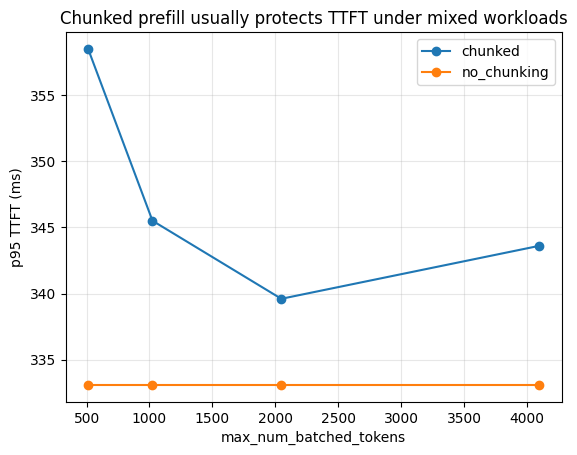

In [6]:

# ============================================================
# Visualize the TTFT tradeoff across token budgets
# ============================================================
# The chart is intentionally simple:
# - x-axis: token budget
# - y-axis: p95 TTFT
# - one line per policy
#
# This is the kind of picture you want in your head during interviews.

plot_df = budget_df.copy()

for policy_name in plot_df["policy"].unique():
    sub = plot_df[plot_df["policy"] == policy_name].sort_values("max_num_batched_tokens")
    plt.plot(sub["max_num_batched_tokens"], sub["p95_TTFT_ms"], marker="o", label=policy_name)

plt.xlabel("max_num_batched_tokens")
plt.ylabel("p95 TTFT (ms)")
plt.title("Chunked prefill usually protects TTFT under mixed workloads")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### What to notice

1. **Chunking is usually about fairness and latency smoothing**, not just raw throughput.

2. **Decode protection matters.**  
   Short interactive requests often care more about keeping decode moving than about maximizing the progress of one giant prompt.

3. **The token budget is a control knob, not a magic constant.**  
   Too small:
   - poor throughput
   - too many scheduler turns

   Too large:
   - long prefills can crowd out interactive work
   - tail latency gets ugly

4. A strong candidate says something like:
   > "I would tune token budgets against the real prompt-length distribution and optimize for admitted p95 TTFT / ITL, not just aggregate tokens/sec."

That is much stronger than saying:
> "I would just set the biggest batch size possible."


## 5. Multi-GPU serving: tensor vs pipeline vs data vs expert parallelism

A lot of candidates answer multi-GPU questions too mechanically.

### The wrong answer
"More GPUs means 8x more tokens/sec."

### The better answer
"It depends on which resource is limiting us and what kind of parallelism we use."

Quick intuition:

- **Tensor parallelism (TP)**
  - split layer math across GPUs
  - usually the default choice for large dense models
  - lowers per-GPU weight memory
  - adds per-step communication

- **Pipeline parallelism (PP)**
  - split layers across GPUs by stage
  - helps when the model is too large or TP is not enough
  - can introduce bubbles and stage imbalance
  - often worse for decode latency than people expect

- **Data parallelism (DP)**
  - replicate full serving workers
  - great for throughput scaling when the model already fits
  - does not reduce per-replica model memory

- **Expert parallelism (EP)**
  - relevant for MoE models
  - experts live on different devices
  - can be great for MoE efficiency
  - adds routing / all-to-all style concerns

Let's build a small estimator.


In [7]:

# ============================================================
# Multi-GPU strategy estimator
# ============================================================
# This is a simplified latency model.
#
# We separate:
# - useful compute
# - communication cost
# - pipeline bubbles / imbalance
#
# The exact constants are illustrative.
# The reasoning pattern is the important part.

@dataclass
class ServingWorkload:
    name: str
    prefill_ms_single_gpu: float
    decode_ms_per_token_single_gpu: float
    memory_gb_single_gpu: float
    is_moe: bool = False


def estimate_strategy(
    workload: ServingWorkload,
    strategy: str,
    gpu_count: int,
) -> Dict[str, float]:
    compute_prefill = workload.prefill_ms_single_gpu
    compute_decode = workload.decode_ms_per_token_single_gpu
    memory = workload.memory_gb_single_gpu

    if strategy == "single":
        return {
            "strategy": "single",
            "gpu_count": gpu_count,
            "prefill_ms": compute_prefill,
            "decode_ms_per_token": compute_decode,
            "memory_gb_per_gpu": memory,
        }

    if strategy == "tensor_parallel":
        # Compute scales down, but not perfectly.
        # Communication cost grows with group size.
        efficiency = 0.86 if gpu_count <= 4 else 0.78
        comm_prefill = 2.0 * math.log2(gpu_count)
        comm_decode = 0.18 * math.log2(gpu_count)
        return {
            "strategy": f"TP-{gpu_count}",
            "gpu_count": gpu_count,
            "prefill_ms": compute_prefill / (gpu_count * efficiency) + comm_prefill,
            "decode_ms_per_token": compute_decode / (gpu_count * efficiency) + comm_decode,
            "memory_gb_per_gpu": memory / gpu_count,
        }

    if strategy == "pipeline_parallel":
        # Pipeline parallelism reduces memory by splitting layers into stages,
        # but decode has stage handoffs and pipeline bubbles.
        stage_imbalance = 1.12
        bubble_ms_prefill = 1.5 * gpu_count
        bubble_ms_decode = 0.30 * (gpu_count - 1)
        return {
            "strategy": f"PP-{gpu_count}",
            "gpu_count": gpu_count,
            "prefill_ms": compute_prefill / gpu_count * stage_imbalance + bubble_ms_prefill,
            "decode_ms_per_token": compute_decode * stage_imbalance + bubble_ms_decode,
            "memory_gb_per_gpu": memory / gpu_count,
        }

    if strategy == "data_parallel":
        # Data parallel does not improve single-request latency much.
        # It mostly helps cluster throughput because you now have more replicas.
        return {
            "strategy": f"DP-{gpu_count}",
            "gpu_count": gpu_count,
            "prefill_ms": compute_prefill,
            "decode_ms_per_token": compute_decode,
            "memory_gb_per_gpu": memory,
        }

    if strategy == "expert_parallel":
        # For MoE, only experts can be partitioned efficiently in this toy model.
        # Dense parts remain.
        if not workload.is_moe:
            return {
                "strategy": f"EP-{gpu_count}",
                "gpu_count": gpu_count,
                "prefill_ms": float("nan"),
                "decode_ms_per_token": float("nan"),
                "memory_gb_per_gpu": float("nan"),
            }
        dense_fraction = 0.45
        expert_fraction = 0.55
        expert_efficiency = 0.84
        all_to_all_prefill = 3.0 * math.log2(gpu_count)
        all_to_all_decode = 0.25 * math.log2(gpu_count)

        prefill = compute_prefill * dense_fraction + compute_prefill * expert_fraction / (gpu_count * expert_efficiency) + all_to_all_prefill
        decode = compute_decode * dense_fraction + compute_decode * expert_fraction / (gpu_count * expert_efficiency) + all_to_all_decode
        return {
            "strategy": f"EP-{gpu_count}",
            "gpu_count": gpu_count,
            "prefill_ms": prefill,
            "decode_ms_per_token": decode,
            "memory_gb_per_gpu": memory * dense_fraction + memory * expert_fraction / gpu_count,
        }

    raise ValueError(f"Unknown strategy: {strategy}")


dense_workload = ServingWorkload(
    name="Dense 70B-ish interactive serving",
    prefill_ms_single_gpu=140.0,
    decode_ms_per_token_single_gpu=7.0,
    memory_gb_single_gpu=140.0,
    is_moe=False,
)

moe_workload = ServingWorkload(
    name="MoE serving workload",
    prefill_ms_single_gpu=180.0,
    decode_ms_per_token_single_gpu=8.0,
    memory_gb_single_gpu=180.0,
    is_moe=True,
)

rows = []
for wl in [dense_workload, moe_workload]:
    for strategy, counts in [
        ("single", [1]),
        ("tensor_parallel", [2, 4, 8]),
        ("pipeline_parallel", [2, 4, 8]),
        ("data_parallel", [2, 4, 8]),
        ("expert_parallel", [2, 4, 8]),
    ]:
        for count in counts:
            record = estimate_strategy(wl, strategy, count)
            record["workload"] = wl.name
            rows.append(record)

parallel_df = pd.DataFrame(rows)
parallel_df.round(2)


,strategy,gpu_count,prefill_ms,decode_ms_per_token,memory_gb_per_gpu,workload
0,single,1,140.00,7.00,140.00,Dense 70B-ish interactive serving
1,TP-2,2,83.40,4.25,70.00,Dense 70B-ish interactive serving
2,TP-4,4,44.70,2.39,35.00,Dense 70B-ish interactive serving
3,TP-8,8,28.44,1.66,17.50,Dense 70B-ish interactive serving
4,PP-2,2,81.40,8.14,70.00,Dense 70B-ish interactive serving
5,PP-4,4,45.20,8.74,35.00,Dense 70B-ish interactive serving
6,PP-8,8,31.60,9.94,17.50,Dense 70B-ish interactive serving
7,DP-2,2,140.00,7.00,140.00,Dense 70B-ish interactive serving
8,DP-4,4,140.00,7.00,140.00,Dense 70B-ish interactive serving
9,DP-8,8,140.00,7.00,140.00,Dense 70B-ish interactive serving


### What to notice

1. **DP helps cluster throughput more than single-request latency.**

2. **TP is often the default serving answer for large dense models** because it reduces per-GPU memory and usually keeps latency better than pure PP.

3. **PP helps fit models, but decode can suffer** because every token must move through stages.

4. **EP becomes interesting mainly for MoE models.**

A strong interview answer is not:
> "Use 8 GPUs."

A strong answer is closer to:
> "For a dense 70B-style interactive service, I would first look at TP because I need the model to fit and I care about decode latency. I would only lean harder on PP if memory or topology forced me to."


## 6. Speculative decoding

Speculative decoding is a classic "sounds magical until you understand the tradeoff" topic.

### Core idea
Use a cheaper **draft model** (or draft mechanism) to propose multiple future tokens.  
The main model verifies them in fewer expensive steps.

### Why it can help
LLM inference is often **memory-bound** at decode time.  
If the verifier can accept multiple draft tokens in one go, you reduce expensive target-model decode passes.

### Why it can fail
If:
- acceptance is low
- draft overhead is high
- traffic is already very high / saturated
- the workload is not memory-bound

then speculation can deliver little benefit or even regress latency.


In [8]:

# ============================================================
# Speculative decoding simulator
# ============================================================
# We model baseline decode as:
# - one expensive target-model pass per generated token
#
# We model speculation as:
# - one cheap draft pass proposing K tokens
# - one target-model verification pass
# - accepted prefix length depends on acceptance probability
#
# This is intentionally simplified, but it gives strong intuition for:
# - when speculation helps
# - why acceptance rate matters
# - why draft overhead matters

def sample_accepted_prefix_length(k: int, accept_prob: float) -> int:
    # We sample how many drafted tokens are accepted in order before the first mismatch.
    accepted = 0
    for _ in range(k):
        if random.random() < accept_prob:
            accepted += 1
        else:
            break
    return accepted


def simulate_speculative_decoding(
    output_tokens: int,
    draft_k: int,
    accept_prob: float,
    target_ms_per_pass: float,
    draft_ms_per_pass: float,
    trials: int = 400,
) -> Dict[str, float]:
    baseline_latencies = []
    speculative_latencies = []
    accepted_tokens_per_verifier_pass = []

    for _ in range(trials):
        # Baseline: one target pass per token.
        baseline_latencies.append(output_tokens * target_ms_per_pass)

        produced = 0
        latency_ms = 0.0
        verifier_passes = 0
        accepted_total = 0

        while produced < output_tokens:
            latency_ms += draft_ms_per_pass
            verifier_passes += 1
            latency_ms += target_ms_per_pass

            accepted = sample_accepted_prefix_length(draft_k, accept_prob)

            # In many speculative schemes, even if all drafted tokens are accepted,
            # the verifier can also contribute progress.
            # For teaching simplicity, we guarantee at least one token of progress.
            progress = max(1, accepted)

            produced += min(progress, output_tokens - produced)
            accepted_total += accepted

        speculative_latencies.append(latency_ms)
        accepted_tokens_per_verifier_pass.append(accepted_total / verifier_passes if verifier_passes else 0.0)

    baseline_avg = statistics.mean(baseline_latencies)
    speculative_avg = statistics.mean(speculative_latencies)
    speedup = baseline_avg / speculative_avg

    return {
        "draft_k": draft_k,
        "accept_prob": accept_prob,
        "target_ms_per_pass": target_ms_per_pass,
        "draft_ms_per_pass": draft_ms_per_pass,
        "baseline_avg_ms": round(baseline_avg, 2),
        "speculative_avg_ms": round(speculative_avg, 2),
        "speedup_x": round(speedup, 3),
        "avg_accepted_tokens_per_verifier_pass": round(statistics.mean(accepted_tokens_per_verifier_pass), 3),
    }


spec_rows = []
for accept_prob in [0.35, 0.50, 0.65, 0.80, 0.92]:
    for draft_k in [2, 4, 6, 8]:
        spec_rows.append(
            simulate_speculative_decoding(
                output_tokens=128,
                draft_k=draft_k,
                accept_prob=accept_prob,
                target_ms_per_pass=6.5,
                draft_ms_per_pass=1.2,
            )
        )

spec_df = pd.DataFrame(spec_rows)
spec_df.head(12)


,draft_k,accept_prob,target_ms_per_pass,draft_ms_per_pass,baseline_avg_ms,speculative_avg_ms,speedup_x,avg_accepted_tokens_per_verifier_pass
0,2,0.35,6.5,1.2,832.0,878.97,0.947,0.475
1,4,0.35,6.5,1.2,832.0,834.33,0.997,0.539
2,6,0.35,6.5,1.2,832.0,831.89,1.000,0.542
3,8,0.35,6.5,1.2,832.0,829.29,1.003,0.543
4,2,0.50,6.5,1.2,832.0,788.08,1.056,0.757
5,4,0.50,6.5,1.2,832.0,687.23,1.211,0.952
6,6,0.50,6.5,1.2,832.0,667.63,1.246,0.991
7,8,0.50,6.5,1.2,832.0,664.01,1.253,1.003
8,2,0.65,6.5,1.2,832.0,695.10,1.197,1.079
9,4,0.65,6.5,1.2,832.0,530.66,1.568,1.532


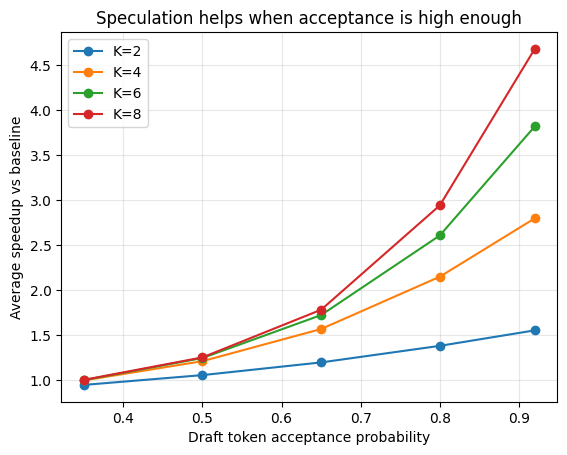

In [9]:

# ============================================================
# Plot speedup vs acceptance probability
# ============================================================
# We plot multiple draft lengths to show:
# - larger K can help
# - but only if acceptance is high enough
# - otherwise extra draft work is wasted

for draft_k in sorted(spec_df["draft_k"].unique()):
    sub = spec_df[spec_df["draft_k"] == draft_k].sort_values("accept_prob")
    plt.plot(sub["accept_prob"], sub["speedup_x"], marker="o", label=f"K={draft_k}")

plt.xlabel("Draft token acceptance probability")
plt.ylabel("Average speedup vs baseline")
plt.title("Speculation helps when acceptance is high enough")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### What to notice

1. **Acceptance rate is the key variable.**

2. Bigger draft lengths are not automatically better.  
   If acceptance is low, more speculative work just means more wasted work.

3. A strong answer usually includes:
   - expected acceptance rate
   - draft overhead
   - whether the workload is memory-bound
   - whether the cluster is already saturated

Interview-quality answer:
> "I would benchmark speculation on my real workload, because it can reduce ITL nicely in the right regime, but low acceptance or high saturation can erase the benefit."


## 7. Quantization for serving

Candidates often discuss quantization too abstractly.

### The useful serving lens
Quantization changes at least three operational things:

1. **Weight memory**
2. **Sometimes bandwidth / latency**
3. **How much room is left for KV cache and concurrency**

It is not enough to say:
> "INT4 makes the model 4x smaller."

You also need to ask:
- which kernels exist on this hardware?
- does this mode work with tensor parallelism?
- what happens to accuracy?
- what happens to throughput under real traffic?
- did I free enough memory to materially improve concurrency?


In [10]:

# ============================================================
# Quantization capacity calculator
# ============================================================
# We calculate:
# - per-GPU weight memory under different precisions
# - how much VRAM remains for KV cache
# - how many concurrent requests we can support at a chosen context length
#
# This lets us connect quantization to actual serving capacity.

@dataclass
class QuantScenario:
    name: str
    weight_bits: float
    kv_bytes: float


def weight_gb(param_count_billions: float, bits: float) -> float:
    return (param_count_billions * 1e9 * bits / 8) / (1024 ** 3)


def max_concurrency_for_context(
    available_kv_gb_per_gpu: float,
    kv_gb_per_request_per_gpu: float,
) -> int:
    if kv_gb_per_request_per_gpu <= 0:
        return 0
    return max(0, int(available_kv_gb_per_gpu // kv_gb_per_request_per_gpu))


gpu_memory_gb = 80.0
gpu_counts = [4, 8]
param_count_b = 70.0

quant_scenarios = [
    QuantScenario("BF16 weights + FP16 KV", weight_bits=16, kv_bytes=2.0),
    QuantScenario("FP8 weights + FP8 KV", weight_bits=8, kv_bytes=1.0),
    QuantScenario("INT8 weights + FP8 KV", weight_bits=8, kv_bytes=1.0),
    QuantScenario("INT4 weights + FP8 KV", weight_bits=4, kv_bytes=1.0),
]

context_tokens = [4096, 8192, 16384]

rows = []
for num_gpus in gpu_counts:
    for quant in quant_scenarios:
        # Use the 70B-ish GQA model structure above.
        model = DenseDecoderModelSpec(
            name=quant.name,
            num_layers=80,
            num_kv_heads=8,
            head_dim=128,
            bytes_per_kv_element=quant.kv_bytes,
        )

        total_weight_gb = weight_gb(param_count_b, quant.weight_bits)
        per_gpu_weight_gb = total_weight_gb / num_gpus
        kv_budget_gb = max(0.0, gpu_memory_gb - per_gpu_weight_gb - 6.0)  # keep 6 GB for runtime / fragmentation / misc

        for ctx in context_tokens:
            kv_per_request_gb = model.kv_gb_for_context(ctx)
            max_cc = max_concurrency_for_context(kv_budget_gb, kv_per_request_gb)

            rows.append({
                "gpus": num_gpus,
                "quantization_mode": quant.name,
                "per_gpu_weight_GB": round(per_gpu_weight_gb, 2),
                "kv_budget_GB_per_gpu": round(kv_budget_gb, 2),
                "context_tokens": ctx,
                "kv_GB_per_request_per_gpu": round(kv_per_request_gb, 3),
                "rough_max_concurrency_per_gpu": max_cc,
                "rough_cluster_concurrency": max_cc * num_gpus,
            })

quant_df = pd.DataFrame(rows)
quant_df


,gpus,quantization_mode,per_gpu_weight_GB,kv_budget_GB_per_gpu,context_tokens,kv_GB_per_request_per_gpu,rough_max_concurrency_per_gpu,rough_cluster_concurrency
0,4,BF16 weights + FP16 KV,32.60,41.40,4096,1.250,33,132
1,4,BF16 weights + FP16 KV,32.60,41.40,8192,2.500,16,64
2,4,BF16 weights + FP16 KV,32.60,41.40,16384,5.000,8,32
3,4,FP8 weights + FP8 KV,16.30,57.70,4096,0.625,92,368
4,4,FP8 weights + FP8 KV,16.30,57.70,8192,1.250,46,184
5,4,FP8 weights + FP8 KV,16.30,57.70,16384,2.500,23,92
6,4,INT8 weights + FP8 KV,16.30,57.70,4096,0.625,92,368
7,4,INT8 weights + FP8 KV,16.30,57.70,8192,1.250,46,184
8,4,INT8 weights + FP8 KV,16.30,57.70,16384,2.500,23,92
9,4,INT4 weights + FP8 KV,8.15,65.85,4096,0.625,105,420


### What to notice

1. Quantization is often a **capacity unlock**, not just a kernel trick.

2. If quantization frees enough memory for substantially more KV cache:
   - concurrency goes up
   - queueing can drop
   - tail latency can improve

3. But you still need to validate:
   - kernel support
   - latency under real traffic
   - accuracy / product quality

Interview-quality answer:
> "I would not celebrate smaller weights until I confirm that the freed memory actually turns into more admitted concurrency or better latency on the real workload."


## 8. Production failure scenarios

This is where L6-style answers usually stand out.

Real serving systems fail in ways that are not obvious from a single happy-path benchmark.

Common failure modes:
- **KV cache exhaustion**
- **preemption / recompute storms**
- **tail latency blow-ups from long prompts**
- **low GPU utilization caused by router/tokenizer CPU bottlenecks**
- **NCCL / network issues in TP or EP**
- **bad quantization choice: memory saved but latency not improved**
- **speculation regression: low acceptance, extra overhead**
- **overload: queue explosion, SLO collapse**
- **scheduler mis-tuning: token budget too high or too low**
- **hot prefixes not being reused due to tiny tokenization mismatches**

Let's simulate overload and admission control.


In [11]:

# ============================================================
# Overload and admission control simulation
# ============================================================
# Goal:
# show why sometimes the correct answer is not
# "try to serve everything"
# but instead
# "protect admitted requests and degrade gracefully"
#
# We use a queue with a simple service-time model.
# The exact math is simplified, but the lesson is real.

@dataclass
class SimpleArrival:
    arrival_ms: float
    service_ms: float


def build_overload_workload(num_requests: int, arrival_gap_ms: float, long_tail_fraction: float = 0.15) -> List[SimpleArrival]:
    arrivals = []
    t = 0.0
    for _ in range(num_requests):
        # Most requests are modest.
        if random.random() < long_tail_fraction:
            service_ms = random.uniform(180, 420)
        else:
            service_ms = random.uniform(30, 90)
        arrivals.append(SimpleArrival(t, service_ms))
        t += arrival_gap_ms
    return arrivals


def simulate_queue(arrivals: List[SimpleArrival], max_queue_len: Optional[int]) -> Dict[str, float]:
    # Single-server queue for teaching.
    # In reality, the "server" is a whole serving stack, but the queueing principle is the same.
    finish_time = 0.0
    queue_len = 0
    queue_departures = deque()

    admitted_latencies = []
    rejected = 0

    for req in arrivals:
        # Evict completed requests from the queue-length tracker.
        while queue_departures and queue_departures[0] <= req.arrival_ms:
            queue_departures.popleft()

        queue_len = len(queue_departures)

        if max_queue_len is not None and queue_len >= max_queue_len:
            rejected += 1
            continue

        start_time = max(req.arrival_ms, finish_time)
        finish_time = start_time + req.service_ms
        queue_departures.append(finish_time)
        admitted_latencies.append(finish_time - req.arrival_ms)

    if admitted_latencies:
        avg_latency = statistics.mean(admitted_latencies)
        p95_latency = percentile(admitted_latencies, 95)
    else:
        avg_latency = float("nan")
        p95_latency = float("nan")

    return {
        "requests_total": len(arrivals),
        "requests_admitted": len(admitted_latencies),
        "requests_rejected": rejected,
        "admission_rate": round(len(admitted_latencies) / len(arrivals), 3),
        "avg_latency_ms": round(avg_latency, 1),
        "p95_latency_ms": round(p95_latency, 1),
    }


overload_arrivals = build_overload_workload(num_requests=300, arrival_gap_ms=18.0)

overload_df = pd.DataFrame([
    {"policy": "no_admission_control", **simulate_queue(overload_arrivals, max_queue_len=None)},
    {"policy": "queue_cap_10", **simulate_queue(overload_arrivals, max_queue_len=10)},
    {"policy": "queue_cap_25", **simulate_queue(overload_arrivals, max_queue_len=25)},
    {"policy": "queue_cap_50", **simulate_queue(overload_arrivals, max_queue_len=50)},
])

overload_df


,policy,requests_total,requests_admitted,requests_rejected,admission_rate,avg_latency_ms,p95_latency_ms
0,no_admission_control,300,300,0,1.000,12532.4,23095.3
1,queue_cap_10,300,62,238,0.207,965.4,1586.7
2,queue_cap_25,300,71,229,0.237,2156.3,3063.5
3,queue_cap_50,300,91,209,0.303,4065.7,6192.7


### What to notice

1. Under overload, "serve everything" can destroy latency for everyone.

2. Admission control can reduce admitted tail latency **a lot**, even though it rejects some traffic.

3. Mature systems usually have explicit degradation policies:
   - reject early
   - reduce max output length
   - lower queue caps
   - move long jobs to async / batch
   - reserve capacity for premium / interactive traffic

Interview-quality answer:
> "At overload, I want to protect the latency SLO of admitted traffic. I would rather reject or shed some traffic than silently let the whole system fall over."


## 9. Debugging from metrics: think like a serving engineer

A staff-level interview often gives you a metrics snapshot and asks:
**"What do you think is happening?"**

Let's build a tiny rule-based diagnosis helper.  
The goal is not to be perfect.  
The goal is to practice turning metrics into hypotheses.


In [12]:

# ============================================================
# Tiny diagnosis helper
# ============================================================
# We map a few common metric patterns to likely hypotheses.
# This is a teaching tool for interview thinking.

def diagnose_serving_snapshot(snapshot: Dict[str, float]) -> List[str]:
    hints = []

    ttft = snapshot.get("ttft_ms_p95", 0)
    itl = snapshot.get("itl_ms_p95", 0)
    gpu_util = snapshot.get("gpu_util_pct", 0)
    queue_ms = snapshot.get("queue_ms_p95", 0)
    preemption_rate = snapshot.get("preemption_rate", 0)
    prefix_hit = snapshot.get("prefix_cache_hit_rate", 0)
    nccl_wait = snapshot.get("comm_wait_pct", 0)
    accept_rate = snapshot.get("spec_accept_rate", 0)
    router_cpu = snapshot.get("router_cpu_pct", 0)

    if ttft > 1200 and queue_ms > 600:
        hints.append("Queueing is dominating TTFT. Check overload, admission control, and batch/token-budget tuning.")

    if ttft > 1000 and gpu_util < 45 and router_cpu > 75:
        hints.append("Likely router/tokenizer / CPU-side bottleneck. GPU is underfed.")

    if itl > 60 and preemption_rate > 0.10:
        hints.append("KV cache pressure is likely causing preemption/recompute. Check context length, concurrency, KV precision, and eviction policy.")

    if prefix_hit < 0.15 and ttft > 900:
        hints.append("You may be missing a large prefix reuse opportunity or tokenized prefixes are not identical enough.")

    if nccl_wait > 20:
        hints.append("Communication overhead is high. Investigate TP/EP topology, NCCL health, and message size / overlap behavior.")

    if accept_rate < 0.35 and snapshot.get("spec_enabled", 0) == 1:
        hints.append("Speculative decoding acceptance is low. Draft overhead may outweigh benefit.")

    if not hints:
        hints.append("No single smoking gun from these metrics. Next step: profile per-stage latency and inspect request length distribution.")

    return hints


incident_snapshots = [
    {
        "incident": "A: queue explosion",
        "ttft_ms_p95": 1800,
        "itl_ms_p95": 38,
        "gpu_util_pct": 88,
        "queue_ms_p95": 1200,
        "preemption_rate": 0.04,
        "prefix_cache_hit_rate": 0.25,
        "comm_wait_pct": 7,
        "spec_accept_rate": 0.60,
        "spec_enabled": 1,
        "router_cpu_pct": 42,
    },
    {
        "incident": "B: GPU underfed by front-end",
        "ttft_ms_p95": 1300,
        "itl_ms_p95": 22,
        "gpu_util_pct": 28,
        "queue_ms_p95": 880,
        "preemption_rate": 0.01,
        "prefix_cache_hit_rate": 0.50,
        "comm_wait_pct": 3,
        "spec_accept_rate": 0.00,
        "spec_enabled": 0,
        "router_cpu_pct": 91,
    },
    {
        "incident": "C: KV pressure / recompute storm",
        "ttft_ms_p95": 900,
        "itl_ms_p95": 88,
        "gpu_util_pct": 93,
        "queue_ms_p95": 200,
        "preemption_rate": 0.22,
        "prefix_cache_hit_rate": 0.18,
        "comm_wait_pct": 8,
        "spec_accept_rate": 0.00,
        "spec_enabled": 0,
        "router_cpu_pct": 36,
    },
    {
        "incident": "D: speculation not paying off",
        "ttft_ms_p95": 600,
        "itl_ms_p95": 54,
        "gpu_util_pct": 71,
        "queue_ms_p95": 120,
        "preemption_rate": 0.02,
        "prefix_cache_hit_rate": 0.34,
        "comm_wait_pct": 5,
        "spec_accept_rate": 0.21,
        "spec_enabled": 1,
        "router_cpu_pct": 38,
    },
]

for snapshot in incident_snapshots:
    print("=" * 80)
    print(snapshot["incident"])
    for hint in diagnose_serving_snapshot(snapshot):
        print("-", hint)


A: queue explosion
- Queueing is dominating TTFT. Check overload, admission control, and batch/token-budget tuning.
B: GPU underfed by front-end
- Queueing is dominating TTFT. Check overload, admission control, and batch/token-budget tuning.
- Likely router/tokenizer / CPU-side bottleneck. GPU is underfed.
C: KV pressure / recompute storm
- KV cache pressure is likely causing preemption/recompute. Check context length, concurrency, KV precision, and eviction policy.
D: speculation not paying off
- Speculative decoding acceptance is low. Draft overhead may outweigh benefit.


## 10. Advanced interview-style questions and strong answers

This section follows the same spirit as the example style you attached: practical question, weak answer, strong answer, and why the strong answer is stronger.

Use these as:
- mock interview prompts
- email / take-home talking points
- self-checks before live loops


### Q1: "Our TTFT doubled after onboarding a new RAG workload. Tokens/sec stayed roughly flat. What do you suspect first?"

**Weak answer:**  
"Attention got slower."

**Strong answer:**  
"I'd first suspect prompt-side pressure rather than decode-side pressure. RAG tends to increase prompt length and prompt variance, so TTFT can rise even if steady-state decode throughput looks fine. I'd check the prompt length distribution, queueing time, prefill share of GPU time, and whether long prefills are crowding out short interactive requests. Then I'd test prefix reuse opportunities, chunked prefill, and admission rules for oversized prompts."

**Why this is strong:**  
It separates **TTFT** from aggregate throughput and starts with the most likely workload shift.

---

### Q2: "We enabled speculative decoding, but p95 ITL improved only a little while GPU usage went up. Why?"

**Weak answer:**  
"The implementation is buggy."

**Strong answer:**  
"Not necessarily. I'd first check speculation acceptance rate and draft overhead. If acceptance is low, we're paying extra draft work without skipping enough expensive verifier passes. I'd also check whether the workload is already saturating the target model, because speculation often helps most in the right memory-bound / medium-load regime, not necessarily at peak saturation. If acceptance is poor, I would test smaller draft lengths, n-gram vs draft-model speculation, or just disable it for that traffic class."

**Why this is strong:**  
It explains a realistic failure mode rather than jumping straight to blame.

---

### Q3: "A model now fits after INT4 quantization, but latency got worse. How is that possible?"

**Weak answer:**  
"Quantization should always be faster."

**Strong answer:**  
"Smaller weights do not guarantee lower latency. The kernel path may be worse on that hardware, dequant overhead may be significant, tensor-parallel support may be weaker, or the workload may still be dominated by KV/cache or communication rather than weight bandwidth. I'd compare end-to-end latency, not just model memory, and verify that the quantized path is actually using the intended optimized kernels."

**Why this is strong:**  
It treats quantization as a **system tradeoff**, not a universal speedup.

---

### Q4: "We see high GPU utilization, rising ITL, and frequent preemption warnings. What would you do?"

**Weak answer:**  
"Scale the cluster."

**Strong answer:**  
"I'd treat this as a KV-capacity problem first. Preemption means active sequences are competing for limited KV space, so the system is either swapping or recomputing work. I'd inspect context length growth, concurrency, and output length policies; then test KV precision changes, more aggressive cache reuse, shorter max outputs, or different admission caps. Scaling out may help, but I would first verify whether the bottleneck is actually per-GPU KV pressure rather than pure request volume."

**Why this is strong:**  
It identifies the **resource under pressure** before prescribing a generic fix.

---

### Q5: "You have 8 GPUs. For a dense 70B interactive service, when do you prefer TP over PP?"

**Weak answer:**  
"Always use all 8 GPUs with both."

**Strong answer:**  
"I'd start with TP when I need the model to fit and I care about interactive decode latency, because TP usually preserves the per-token flow better than heavy PP. I would lean more on PP if memory or topology forces it, or if the model simply cannot be served cleanly with TP alone. Then I'd validate with real latency and communication metrics, because the best answer depends on NVLink / fabric quality, batch shape, and whether the workload is TTFT-sensitive or throughput-oriented."

**Why this is strong:**  
It shows **context-dependent engineering judgment**.

---

### Q6: "Our prefix cache hit rate is low even though users all share the same system prompt. Why might that happen?"

**Weak answer:**  
"The cache is broken."

**Strong answer:**  
"It might be a cache bug, but I would first verify token-level identity. Small differences in whitespace, timestamps, request metadata, retrieved context ordering, or tokenizer versioning can turn 'visually identical' prompts into different token sequences. I would inspect the exact tokenized prefix and normalize prompt construction before assuming the runtime reuse layer is wrong."

**Why this is strong:**  
It shows you understand that reuse is determined by **exact token identity**, not visual similarity.

---

### Q7: "Router CPU is pegged, GPU utilization is low, and TTFT is bad. What does that tell you?"

**Weak answer:**  
"The GPUs are too slow."

**Strong answer:**  
"It suggests the GPUs are underfed. I would inspect tokenization, validation, request shaping, JSON/tool constraints, and front-end batching logic before touching kernels. If the front-end is the bottleneck, optimizing GPU kernels will not fix TTFT. This is a classic example of end-to-end latency being dominated by non-GPU stages."

**Why this is strong:**  
It recognizes a common infra reality: the accelerator is not always the bottleneck.

---

### Q8: "Under overload, should we keep accepting requests and let them queue?"

**Weak answer:**  
"Yes, because rejecting requests is bad."

**Strong answer:**  
"Not blindly. If queue growth destroys admitted p95 latency, we may violate the product SLO for everyone. I would usually prefer explicit degradation: queue caps, max-output tightening, traffic shaping, async routing for long jobs, or early rejection. The goal is to protect the latency of admitted interactive traffic instead of silently degrading the whole service."

**Why this is strong:**  
It shows mature thinking about **SLOs, overload behavior, and graceful degradation**.


## 11. Exercises

Try to answer these before opening the answer cells below.


### Exercise 1
Why can a model that "fits in GPU memory" still fail badly in production when traffic rises?

Write a 4–6 sentence answer that mentions:
- weights
- KV cache
- context length
- concurrency


### Exercise 1 — Answer

Because fitting the weights is only the starting point. During serving, every live request also needs KV cache memory, and that memory grows with context length and concurrency. A model may fit at batch size 1 with short prompts, but fail once many long-context requests are active at the same time. That is why serving capacity depends not just on parameter count, but also on request mix, max output length, and KV precision. In practice, many production issues are caused by runtime memory pressure rather than inability to load the model itself.


### Exercise 2
Why can chunked prefill improve user experience even if it does not maximize the progress of the longest prompt?


### Exercise 2 — Answer

Because interactive users usually care most about TTFT and steady decode progress, not about one giant prompt monopolizing the device. Chunked prefill lets the scheduler continue serving short decode work while gradually advancing long prompts. That can protect p95 TTFT and ITL for the majority of traffic. In other words, chunking is often a fairness and latency-smoothing tool, not just a raw throughput trick.


### Exercise 3
You enabled speculative decoding. What are the top 3 metrics or measurements you would inspect to decide whether to keep it on?


### Exercise 3 — Answer

A strong top three would be:
1. **Acceptance rate / accepted draft length** — to see whether the target model is skipping enough expensive work  
2. **End-to-end ITL / latency on the real workload** — not just a microbenchmark  
3. **Target GPU utilization / system saturation** — because speculation may help in one load regime and not another  

A good follow-up is to also inspect draft overhead and whether the workload is memory-bound.


### Exercise 4
When does quantization help operationally even if the raw kernel speedup is modest?


### Exercise 4 — Answer

Quantization can still be a major win when it frees enough memory to materially increase admitted concurrency or reduce queueing. For example, smaller weights may leave more room for KV cache, which means more live requests per GPU before preemption or rejection begins. In that case, the product benefit comes from higher capacity and lower tail latency, not necessarily from dramatically faster single-token kernels. That is why real serving evaluation must include queueing and concurrency, not just isolated throughput.


### Exercise 5
You see these metrics:
- p95 TTFT = very high
- p95 ITL = normal
- GPU utilization = low
- router CPU = high

What is your first hypothesis, and what do you inspect next?


### Exercise 5 — Answer

My first hypothesis is that the GPUs are underfed by the front-end. The next things I would inspect are tokenization cost, request validation, constraint processing, batching logic, and any router-side CPU hot spots. Because ITL is normal, decode itself is probably not the main issue. The problem is likely before the model pass rather than inside it.


### Exercise 6 — Small coding challenge

Modify the chunked prefill simulation so that:
- very long prompts beyond a threshold are routed to a separate async queue
- interactive traffic is protected with a smaller queue cap

Then compare:
- admitted request count
- p95 TTFT
- p95 end-to-end latency

This is a very realistic systems exercise.


## 12. Final interview advice

For L5/L6 inference-serving interviews, aim to sound like somebody who can run a production system, not just recite architecture names.

A strong pattern is:

1. **Name the metric that is bad**
   - TTFT
   - ITL / TPOT
   - throughput
   - p95 / p99
   - rejection rate

2. **Name the likely constrained resource**
   - compute
   - memory bandwidth
   - KV cache capacity
   - network / NCCL
   - CPU / router
   - queue capacity

3. **Propose the next measurements**
   - prompt length distribution
   - queue time
   - prefix hit rate
   - preemption rate
   - GPU util vs communication wait
   - verifier acceptance rate
   - per-stage latency breakdown

4. **Only then propose the fix**

That is the habit that interviewers trust.

Good candidates know the words.  
Strong candidates reason from **symptom -> bottleneck -> measurement -> action**.


## 13. Optional further reading topics

After finishing this notebook, good next topics are:
- disaggregated prefill / decode
- overlap schedulers
- NCCL debugging patterns
- CUDA graphs in decode-heavy paths
- MoE routing and all-to-all pain points
- cache eviction policy design
- admission control by traffic class
- multi-tenant serving isolation
